# Hydrofabric Conflation Visual QA — Texas eBFE Shiloh Branch

This notebook performs a real-data visual review of
`RasHydrofabric.conflate()` using the **Lower Colorado–Cummins** Texas
eBFE/BLE delivery (HUC8 `12090301`) and its 1D **SHILOH BRANCH** reach. It
compares the HEC-RAS footprint, river centerline, and 40 cross sections with
nearby NHDPlus High Resolution flowpaths, then exposes every score component
used to resolve the match.

## What you will verify

- Model footprint, centerline, XS cut lines, flowpaths, and HUC12 boundaries
  align in one projected CRS.
- Candidate rank reflects overlap, distance, direction, XS intersections,
  topology, stream scale, and sequence evidence.
- Accepted links retain `feature_id`, confidence, reasons, and measures.
- A deliberately strict sensitivity run exposes `matched`, `ambiguous`, and
  `unmatched` states without fake accepted COMIDs.

The model is obtained through `RasEbfeModels`. Flowpaths and HUCs come from
the official [USGS NHDPlus HR map service](https://hydro.nationalmap.gov/arcgis/rest/services/NHDPlus_HR/MapServer),
documented by [USGS National Hydrography](https://www.usgs.gov/national-hydrography/access-national-hydrography-products).

> The thresholds here are visual-QA parameters, not ras2fim or production
> acceptance policy. The strict run is intentionally conservative.


In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = True

import logging
import os
import sys
from pathlib import Path
from xml.etree import ElementTree as ET

if USE_LOCAL_SOURCE:
    here = Path.cwd().resolve()
    repo_root = next(
        (
            p
            for p in [here, *here.parents]
            if (p / "ras_commander" / "__init__.py").exists()
        ),
        here,
    )
    sys.path.insert(0, str(repo_root))
    print("LOCAL SOURCE MODE:", repo_root)
else:
    repo_root = Path.cwd().resolve()
    print("PIP PACKAGE MODE")

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pyproj import CRS

import ras_commander
from ras_commander import (
    HdfProject,
    HdfXsec,
    RasCmdr,
    RasHydrofabric,
    RasPlan,
    init_ras_project,
)
from ras_commander.sources.federal import RasEbfeModels

logging.getLogger("ras_commander").setLevel(logging.ERROR)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12})
working_dir = repo_root / "working" / "example_956_hydrofabric_conflation"
working_dir.mkdir(parents=True, exist_ok=True)
print("ras-commander:", ras_commander.__file__)
print("Working cache:", working_dir)

LOCAL SOURCE MODE: \\192.168.3.20\CLB-Engineering\Symphony\ras-commander\hydrofabric-conflate


ras-commander: \\192.168.3.20\CLB-Engineering\Symphony\ras-commander\hydrofabric-conflate\ras_commander\__init__.py
Working cache: \\192.168.3.20\CLB-Engineering\Symphony\ras-commander\hydrofabric-conflate\working\example_956_hydrofabric_conflation


## 1. Reuse or organize the Texas eBFE model

Lower Colorado–Cummins is a Texas 1D steady BLE reach collection. SHILOH
BRANCH is compact enough for legible maps while providing 40 independent XS
checks. The organizer downloads the archive only when it is absent.


In [2]:
BLE_RIVER = "Rabbs Creek-Colorado River"
BLE_REACH_NAME = "SHILOH BRANCH"
RAS_VERSION = "7.0"
EBFE_WORKSPACE = Path(
    os.environ.get("RAS_COMMANDER_EBFE_ROOT", r"H:\Testing\eBFE Model Organization")
)
DOWNLOAD_ROOT = EBFE_WORKSPACE / "Downloads"
ORGANIZED_ROOT = EBFE_WORKSPACE / "Organized"
organized = ORGANIZED_ROOT / "LowerColoradoCummins_12090301"
project_folder = organized / "RAS Model" / BLE_RIVER / BLE_REACH_NAME

if not (project_folder / f"{BLE_REACH_NAME}.prj").exists():
    organized = RasEbfeModels.organize_model(
        "lower-colorado-cummins",
        download_root=DOWNLOAD_ROOT,
        output_root=ORGANIZED_ROOT,
        river=BLE_RIVER,
        reach=BLE_REACH_NAME,
    )
    project_folder = organized / "RAS Model" / BLE_RIVER / BLE_REACH_NAME

print("Organized study:", organized)
print("Project folder:", project_folder)

Organized study: H:\Testing\eBFE Model Organization\Organized\LowerColoradoCummins_12090301
Project folder: H:\Testing\eBFE Model Organization\Organized\LowerColoradoCummins_12090301\RAS Model\Rabbs Creek-Colorado River\SHILOH BRANCH


The original BLE project predates geometry-HDF output. A migrated HDF is
reused when present. On a fresh Windows workspace, ras-commander enables the
necessary run flags and computes the steady plan with HEC-RAS 7.0.


In [3]:
GENERATE_HDF_IF_MISSING = True
ras = init_ras_project(project_folder, RAS_VERSION)
geom_hdf = project_folder / f"{ras.project_name}.g01.hdf"
if not geom_hdf.exists():
    if not GENERATE_HDF_IF_MISSING:
        raise FileNotFoundError(
            f"Set GENERATE_HDF_IF_MISSING=True to create {geom_hdf.name}"
        )
    RasPlan.update_run_flags(
        "01", geometry_preprocessor=True, post_processor=True, ras_object=ras
    )
    RasCmdr.compute_plan("01", ras_object=ras, force_geompre=True)
    ras = init_ras_project(project_folder, RAS_VERSION)
if not geom_hdf.exists():
    raise FileNotFoundError(f"HEC-RAS did not create {geom_hdf}")
print("Geometry HDF:", geom_hdf.name, f"({geom_hdf.stat().st_size:,} bytes)")

Geometry HDF: SHILOH BRANCH.g01.hdf (332,579 bytes)


## 2. Extract and identify HEC-RAS geometry

This legacy delivery stores its authoritative projection WKT in the vendor
XML rather than the HDF. We recover `EPSG:2277` (NAD83 / Texas Central ftUS),
assign it to the public HDF-reader outputs, and add stable IDs.


In [4]:
project_xml = project_folder / f"{ras.project_name}.xml"
projection_wkt = (ET.parse(project_xml).findtext("Projection") or "").strip()
model_crs = CRS.from_wkt(projection_wkt)
cross_sections = HdfXsec.get_cross_sections(geom_hdf).set_crs(
    model_crs, allow_override=True
)
centerlines = HdfXsec.get_river_centerlines(geom_hdf).set_crs(
    model_crs, allow_override=True
)
model_footprints, _ = HdfProject.get_project_extent(
    geom_hdf, geometry_type="footprint", include_2d=False, buffer_percent=0.0
)
model_footprints = model_footprints.set_crs(model_crs, allow_override=True)

geometry_id = "lower-colorado-cummins-shiloh-branch"
model_footprints["geometry_id"] = geometry_id
centerlines["geometry_id"] = geometry_id
centerlines["reach_id"] = (
    centerlines["River Name"].astype(str).str.strip()
    + " / "
    + centerlines["Reach Name"].astype(str).str.strip()
)
cross_sections["geometry_id"] = geometry_id
cross_sections["reach_id"] = (
    cross_sections["River"].astype(str).str.strip()
    + " / "
    + cross_sections["Reach"].astype(str).str.strip()
)
cross_sections["xs_id"] = cross_sections["RS"].astype(str).str.strip()

model_summary = pd.DataFrame(
    {
        "layer": ["model footprint", "river centerline", "cross sections"],
        "features": [len(model_footprints), len(centerlines), len(cross_sections)],
        "geometry_type": [
            ", ".join(sorted(set(g.geom_type)))
            for g in (model_footprints, centerlines, cross_sections)
        ],
    }
)
print("Model CRS:", model_crs.to_authority(), "—", model_crs.name)
display(model_summary)

Model CRS: ('EPSG', '2277') — NAD83 / Texas Central (ftUS)


,layer,features,geometry_type
0,model footprint,1,Polygon
1,river centerline,1,LineString
2,cross sections,40,LineString


## 3. Query NHDPlus HR flowpaths and HUC12 polygons

The query envelope is the footprint plus 1,500 m. Responses are cached under
`working/example_956_hydrofabric_conflation/`; set `REFRESH_USGS=True` to
request current service contents.


In [5]:
SERVICE = "https://hydro.nationalmap.gov/arcgis/rest/services/NHDPlus_HR/MapServer"
REFRESH_USGS = False
query_bounds = model_footprints.to_crs(3857).buffer(1500).to_crs(4326).total_bounds


def query_layer(layer, fields):
    envelope = ",".join(f"{v:.8f}" for v in query_bounds)
    response = requests.get(
        f"{SERVICE}/{layer}/query",
        params={
            "where": "1=1",
            "geometry": envelope,
            "geometryType": "esriGeometryEnvelope",
            "inSR": 4326,
            "spatialRel": "esriSpatialRelIntersects",
            "outFields": fields,
            "returnGeometry": "true",
            "outSR": 4326,
            "f": "geojson",
        },
        timeout=60,
    )
    response.raise_for_status()
    payload = response.json()
    if "error" in payload:
        raise RuntimeError(payload["error"])
    return gpd.GeoDataFrame.from_features(payload["features"], crs="EPSG:4326")


flow_cache = working_dir / "nhdplus_hr_flowpaths.geojson"
huc_cache = working_dir / "nhdplus_hr_huc12.geojson"
if REFRESH_USGS or not (flow_cache.exists() and huc_cache.exists()):
    flowpaths = query_layer(
        3,
        "nhdplusid,fromnode,tonode,streamorde,totdasqkm,hydroseq,"
        "gnis_name,ftype,mainpath,lengthkm",
    )
    hucs = query_layer(12, "huc12,name,states,areasqkm")
    flowpaths.to_file(flow_cache, driver="GeoJSON")
    hucs.to_file(huc_cache, driver="GeoJSON")
    cache_state = "queried and cached"
else:
    flowpaths, hucs = gpd.read_file(flow_cache), gpd.read_file(huc_cache)
    cache_state = "loaded from working cache"
flowpaths = flowpaths.loc[
    flowpaths.geometry.notna() & ~flowpaths.geometry.is_empty
].copy()
hucs = hucs.loc[hucs.geometry.notna() & ~hucs.geometry.is_empty].copy()
print(f"NHDPlus HR flowpaths: {len(flowpaths)} ({cache_state})")
print(f"HUC12 polygons: {len(hucs)}")
display(hucs[["huc12", "name"]].sort_values("huc12").reset_index(drop=True))

NHDPlus HR flowpaths: 101 (loaded from working cache)
HUC12 polygons: 3


,huc12,name
0,120903010503,Little Pin Oak Creek
1,120903010506,Lower Rabbs Creek
2,120903010507,Cedar Creek-Colorado River


### Source-data alignment map

First verify that the model and hydrofabric occupy the same corridor. The
light-blue network is the full query; black and gray are HEC-RAS geometry.


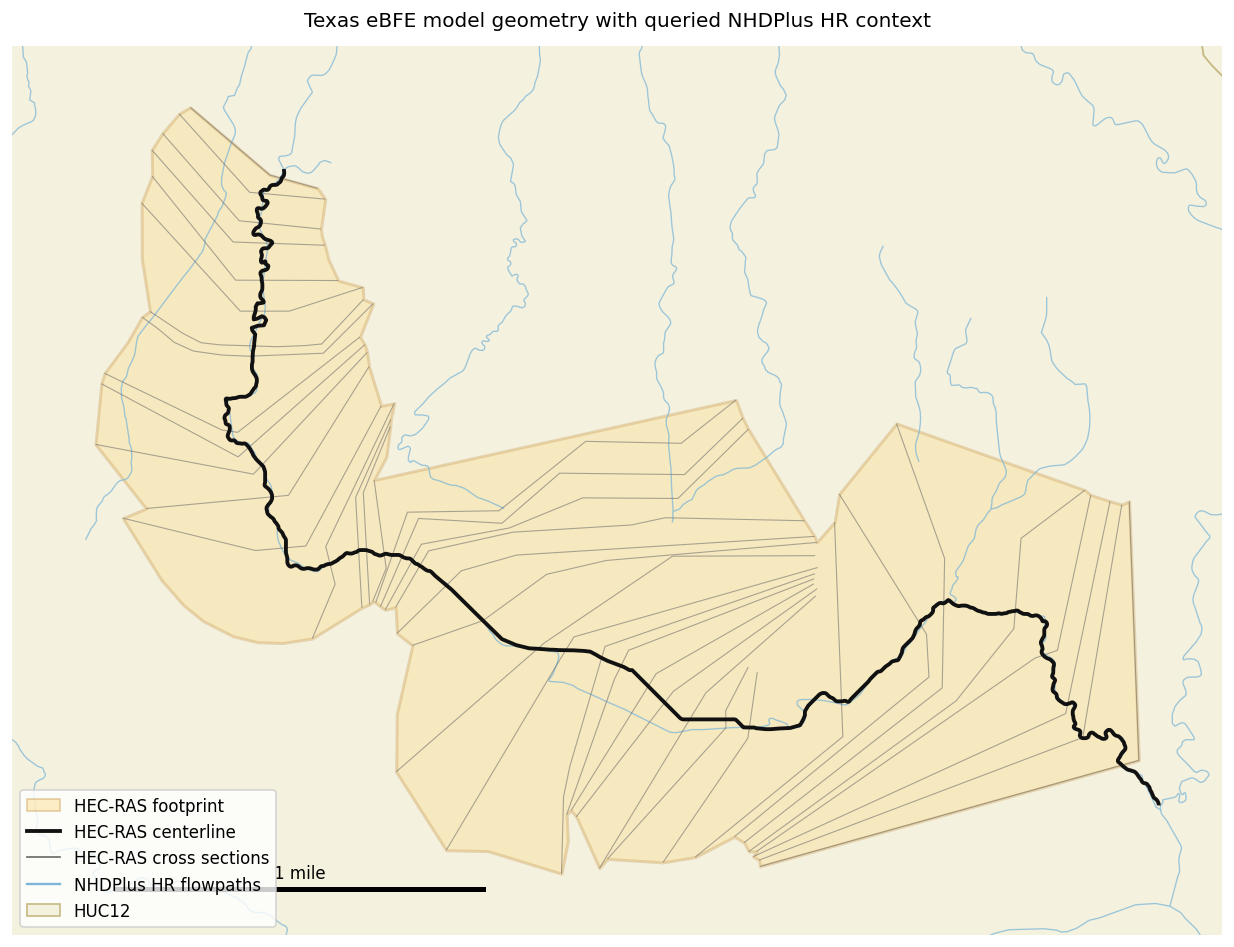

In [6]:
flowpaths_model, hucs_model = flowpaths.to_crs(model_crs), hucs.to_crs(model_crs)
fig, ax = plt.subplots(figsize=(11, 8))
hucs_model.plot(ax=ax, color="#f4f1de", edgecolor="#c7b983", linewidth=1)
flowpaths_model.plot(ax=ax, color="#7db7d8", linewidth=0.8, alpha=0.75)
model_footprints.plot(ax=ax, color="#ffd166", edgecolor="#b7791f", lw=1.8, alpha=0.25)
cross_sections.plot(ax=ax, color="#666666", linewidth=0.65, alpha=0.55)
centerlines.plot(ax=ax, color="#111111", linewidth=2.3)
xmin, ymin, xmax, ymax = model_footprints.total_bounds
xp, yp = (xmax - xmin) * 0.08, (ymax - ymin) * 0.08
ax.set(xlim=(xmin - xp, xmax + xp), ylim=(ymin - yp, ymax + yp), aspect="equal")
sx, sy = xmin + xp * 0.25, ymin - yp * 0.25
ax.plot([sx, sx + 5280], [sy, sy], color="black", lw=3)
ax.text(sx + 2640, sy + yp * 0.12, "1 mile", ha="center", va="bottom")
ax.set_axis_off()
ax.set_title("Texas eBFE model geometry with queried NHDPlus HR context", pad=12)
ax.legend(
    handles=[
        Patch(
            facecolor="#ffd166",
            edgecolor="#b7791f",
            alpha=0.35,
            label="HEC-RAS footprint",
        ),
        Line2D([0], [0], color="#111111", lw=2.3, label="HEC-RAS centerline"),
        Line2D([0], [0], color="#666666", lw=1, label="HEC-RAS cross sections"),
        Line2D([0], [0], color="#7db7d8", lw=1.4, label="NHDPlus HR flowpaths"),
        Patch(facecolor="#f4f1de", edgecolor="#c7b983", label="HUC12"),
    ],
    loc="lower left",
)
plt.tight_layout()
plt.show()

## 4. Run multi-criteria conflation

The NHDPlus adapter normalizes IDs, stream order, drainage area, node
connectivity, and hydrosequence. HUC intersections are reporting evidence and
do not influence the candidate score.


In [7]:
result = RasHydrofabric.conflate(
    model_footprints,
    centerlines,
    cross_sections,
    flowpaths,
    adapter="nhdplus",
    hucs=hucs,
    huc_id_col="huc12",
    max_candidates=8,
    min_confidence=0.55,
    ambiguity_margin=0.05,
)
status_order = ["matched", "ambiguous", "unmatched"]
status_by_element = pd.crosstab(result.matches.element_type, result.matches.status)
status_by_element = status_by_element.reindex(columns=status_order, fill_value=0)
status_by_element["total"] = status_by_element.sum(axis=1)
print("Adapter:", result.adapter, "| Analysis CRS:", result.analysis_crs)
print("Parameters:", result.parameters)
display(status_by_element)

reach_match = result.matches.loc[result.matches.element_type == "reach"].iloc[0]
reach_candidates = (
    result.candidates.loc[result.candidates.element_type == "reach"]
    .sort_values("candidate_rank")
    .copy()
)
print(
    f"Accepted reach feature: {reach_match.feature_id}; "
    f"confidence={reach_match.confidence_score:.3f}; margin={reach_match.score_margin:.3f}"
)
display(
    reach_candidates[
        [
            "candidate_rank",
            "feature_id",
            "confidence_score",
            "centerline_mean_distance",
            "angular_difference_deg",
            "xs_intersection_count",
            "xs_total_count",
            "stream_order",
            "drainage_area",
            "reason_codes",
        ]
    ].reset_index(drop=True)
)

Adapter: nhdplus | Analysis CRS: EPSG:2277
Parameters: {'weights': {'footprint_overlap': 0.15, 'centerline_distance': 0.2, 'direction_agreement': 0.12, 'xs_intersections': 0.18, 'topological_continuity': 0.15, 'stream_order_drainage_area': 0.1, 'sequence_consistency': 0.1}, 'search_distance': 6322.941270214319, 'topology_tolerance': 505.83530161714555, 'max_candidates': 8, 'min_confidence': 0.55, 'ambiguity_margin': 0.05, 'sample_count': 9}


status,matched,ambiguous,unmatched,total
element_type,,,,
cross_section,40,0,0,40
geometry,1,0,0,1
reach,1,0,0,1


Accepted reach feature: 30000300010092; confidence=0.834; margin=0.212


,candidate_rank,feature_id,confidence_score,centerline_mean_distance,angular_difference_deg,xs_intersection_count,xs_total_count,stream_order,drainage_area,reason_codes
0,1,30000300010092,0.834255,990.354758,24.931132,30,40,2.0,5.4810,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
1,2,30000300028147,0.622211,2801.152182,18.940499,5,40,3.0,10.0982,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
2,3,30000300059049,0.601566,2586.819248,37.067306,2,40,2.0,5.7988,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
3,4,30000300089730,0.599054,2827.650702,3.727158,0,40,2.0,5.8016,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
4,5,30000300047471,0.589503,2813.902882,27.204819,0,40,2.0,5.4998,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
5,6,30000300120564,0.550973,2498.449469,68.215138,3,40,2.0,6.6386,"(FOOTPRINT_OVERLAP_STRONG,)"
6,7,30000300003613,0.508878,3360.951127,55.258450,0,40,2.0,1.4264,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
7,8,30000300083412,0.495213,3184.711802,69.024143,0,40,2.0,1.4438,"(FOOTPRINT_OVERLAP_STRONG, SEQUENCE_CONSISTENT)"


### Candidate map and direct XS evidence

Red points mark exact intersections of rank 1 with XS cut lines. Ranks 2–8
remain visible for review rather than disappearing after acceptance.


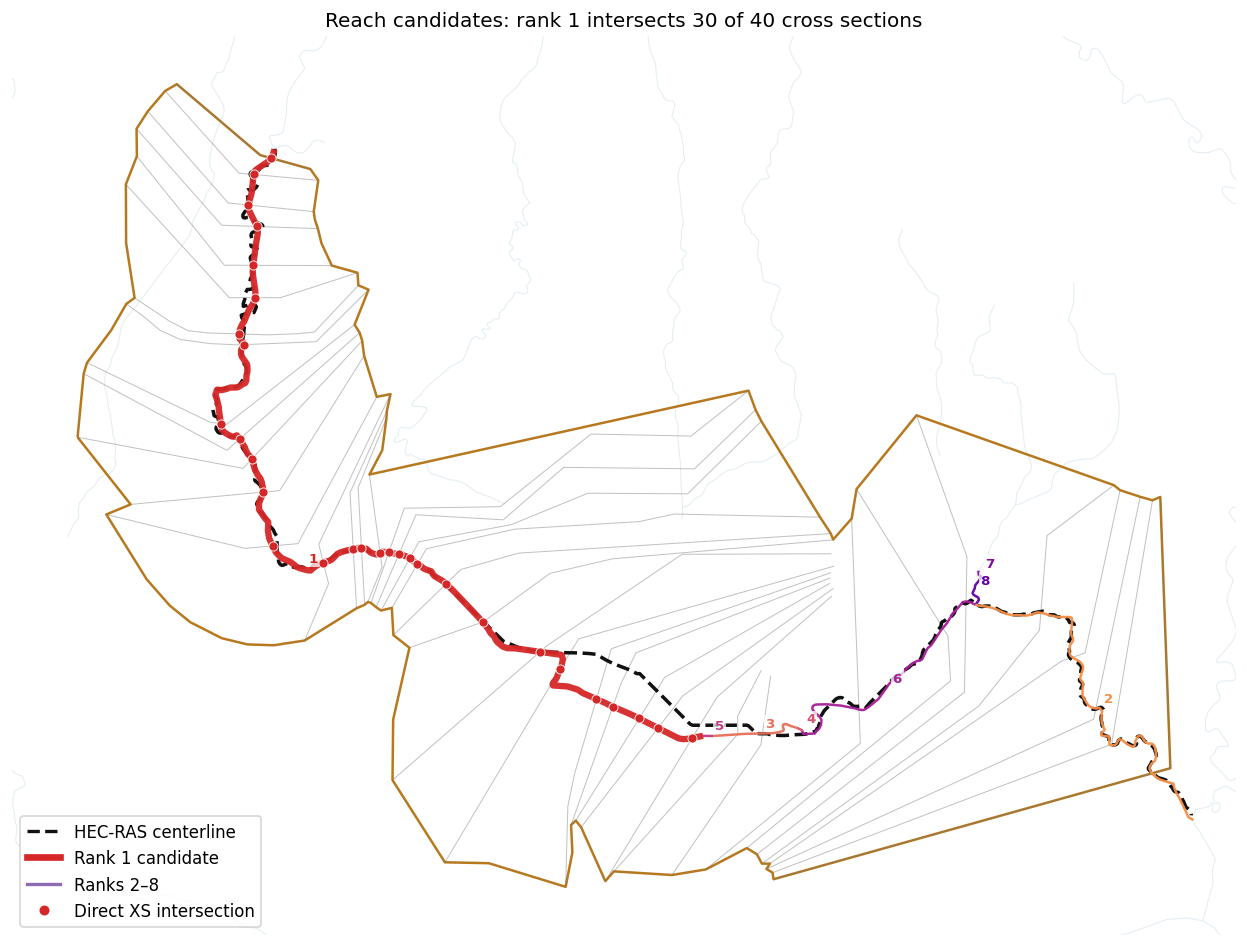

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))
flowpaths_model.plot(ax=ax, color="#d8e8f0", linewidth=0.65, alpha=0.7)
model_footprints.boundary.plot(ax=ax, color="#b7791f", linewidth=1.5)
cross_sections.plot(ax=ax, color="#777777", linewidth=0.6, alpha=0.45)
centerlines.plot(ax=ax, color="#111111", linewidth=2.1, linestyle="--")
colors = plt.cm.plasma_r(np.linspace(0.18, 0.82, len(reach_candidates)))
for color, (_, candidate) in zip(colors[::-1], reach_candidates.iloc[::-1].iterrows()):
    rank = int(candidate.candidate_rank)
    line_color, width = ("#d62728", 3.8) if rank == 1 else (color, 1.5)
    gpd.GeoSeries([candidate.geometry], crs=result.analysis_crs).plot(
        ax=ax, color=line_color, linewidth=width, alpha=0.95
    )
    midpoint = candidate.geometry.interpolate(0.5, normalized=True)
    ax.annotate(
        str(rank),
        (midpoint.x, midpoint.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        weight="bold",
        color=line_color,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1},
    )
top_flowpath = reach_candidates.iloc[0].geometry
intersections = cross_sections.geometry.intersection(top_flowpath)
points = gpd.GeoDataFrame(
    geometry=intersections.loc[~intersections.is_empty], crs=model_crs
)
points = points.explode(index_parts=False)
points.loc[points.geom_type.isin(["Point", "MultiPoint"])].plot(
    ax=ax, color="#d62728", edgecolor="white", linewidth=0.5, markersize=30, zorder=8
)
xmin, ymin, xmax, ymax = model_footprints.total_bounds
xp, yp = (xmax - xmin) * 0.06, (ymax - ymin) * 0.06
ax.set(xlim=(xmin - xp, xmax + xp), ylim=(ymin - yp, ymax + yp), aspect="equal")
ax.set_axis_off()
ax.set_title(
    f"Reach candidates: rank 1 intersects {int(reach_candidates.iloc[0].xs_intersection_count)} "
    f"of {int(reach_candidates.iloc[0].xs_total_count)} cross sections"
)
ax.legend(
    handles=[
        Line2D([0], [0], color="#111111", lw=2, ls="--", label="HEC-RAS centerline"),
        Line2D([0], [0], color="#d62728", lw=4, label="Rank 1 candidate"),
        Line2D([0], [0], color="#8c6bb1", lw=2, label="Ranks 2–8"),
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="#d62728",
            markeredgecolor="white",
            markersize=7,
            label="Direct XS intersection",
        ),
    ],
    loc="lower left",
)
plt.tight_layout()
plt.show()

### Score-component audit

Gray means evidence unavailable and its weight was renormalized away. A
one-reach model has no model-to-model topology neighbor, so that column is n/a.


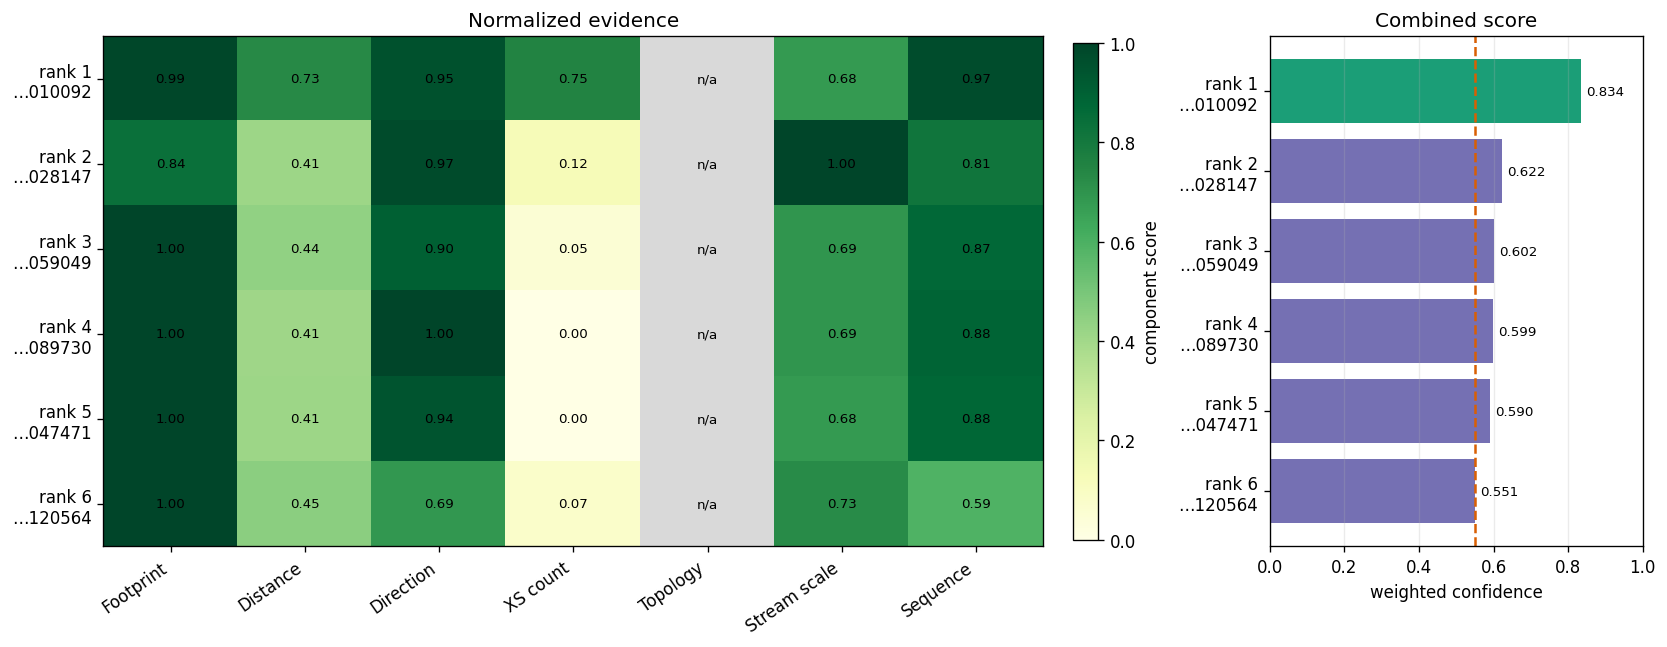

In [9]:
score_columns = [
    "footprint_overlap_score",
    "centerline_distance_score",
    "direction_agreement_score",
    "xs_intersection_score",
    "topological_continuity_score",
    "hydrologic_score",
    "sequence_consistency_score",
]
labels = [
    "Footprint",
    "Distance",
    "Direction",
    "XS count",
    "Topology",
    "Stream scale",
    "Sequence",
]
view = reach_candidates.head(6)
matrix = view[score_columns].to_numpy(dtype=float)
ylabels = [
    f"rank {int(r)}\n…{str(fid)[-6:]}"
    for r, fid in zip(view.candidate_rank, view.feature_id)
]
fig, (heat, total) = plt.subplots(
    1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [3.2, 1.2]}
)
cmap = plt.cm.YlGn.copy()
cmap.set_bad("#d9d9d9")
image = heat.imshow(
    np.ma.masked_invalid(matrix), vmin=0, vmax=1, cmap=cmap, aspect="auto"
)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        heat.text(
            j,
            i,
            "n/a" if np.isnan(matrix[i, j]) else f"{matrix[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )
heat.set_xticks(range(len(labels)), labels, rotation=35, ha="right")
heat.set_yticks(range(len(ylabels)), ylabels)
heat.set_title("Normalized evidence")
fig.colorbar(image, ax=heat, fraction=0.025, pad=0.03, label="component score")
totals = view.confidence_score.to_numpy()
bars = total.barh(
    range(len(totals)), totals, color=["#1b9e77"] + ["#7570b3"] * (len(totals) - 1)
)
total.axvline(result.parameters["min_confidence"], color="#d95f02", ls="--", lw=1.5)
total.set_yticks(range(len(ylabels)), ylabels)
total.invert_yaxis()
total.set_xlim(0, 1)
total.set_xlabel("weighted confidence")
total.set_title("Combined score")
total.bar_label(bars, labels=[f"{v:.3f}" for v in totals], padding=3, fontsize=8)
total.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Inspect explicit ambiguous and unmatched states

The same evidence is re-resolved with `min_confidence=0.80` and
`ambiguity_margin=0.25`. Best candidates remain reviewable, but accepted
`feature_id` is null for every unresolved row.


In [10]:
strict_result = RasHydrofabric.conflate(
    model_footprints,
    centerlines,
    cross_sections,
    flowpaths,
    adapter="nhdplus",
    hucs=hucs,
    huc_id_col="huc12",
    max_candidates=8,
    min_confidence=0.80,
    ambiguity_margin=0.25,
)
strict_status = pd.crosstab(
    strict_result.matches.element_type, strict_result.matches.status
)
strict_status = strict_status.reindex(columns=status_order, fill_value=0)
strict_status["total"] = strict_status.sum(axis=1)
unresolved = strict_result.matches.loc[strict_result.matches.status != "matched"]
assert unresolved.feature_id.isna().all()
display(strict_status)
display(
    unresolved[
        [
            "element_type",
            "reach_id",
            "xs_id",
            "feature_id",
            "best_candidate_feature_id",
            "status",
            "confidence_score",
            "score_margin",
            "match_method",
            "reason_codes",
        ]
    ].head(12)
)

status,matched,ambiguous,unmatched,total
element_type,,,,
cross_section,30,0,10,40
geometry,0,1,0,1
reach,0,1,0,1


,element_type,reach_id,xs_id,feature_id,best_candidate_feature_id,status,confidence_score,score_margin,match_method,reason_codes
0,geometry,NaN,NaN,NaN,30000300010092,ambiguous,0.883979,0.148431,multi_criteria_ambiguous,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
1,reach,SHILOH BRANCH / Reach-1,NaN,NaN,30000300010092,ambiguous,0.834255,0.212044,multi_criteria_ambiguous,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
2,cross_section,SHILOH BRANCH / Reach-1,10041,NaN,30000300059049,unmatched,0.721096,0.064518,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
25,cross_section,SHILOH BRANCH / Reach-1,2079,NaN,30000300028147,unmatched,0.735548,0.127906,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
34,cross_section,SHILOH BRANCH / Reach-1,2772,NaN,30000300028147,unmatched,0.735548,0.126639,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
35,cross_section,SHILOH BRANCH / Reach-1,3701,NaN,30000300028147,unmatched,0.735548,0.125669,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
36,cross_section,SHILOH BRANCH / Reach-1,4729,NaN,30000300028147,unmatched,0.735548,0.124487,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
37,cross_section,SHILOH BRANCH / Reach-1,5834,NaN,30000300120564,unmatched,0.685681,0.071792,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_STRONG, XS_DIRECT_INTERSECT..."
38,cross_section,SHILOH BRANCH / Reach-1,6333,NaN,30000300120564,unmatched,0.685681,0.068485,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_STRONG, XS_DIRECT_INTERSECT..."
39,cross_section,SHILOH BRANCH / Reach-1,8015,NaN,30000300120564,unmatched,0.685681,0.065693,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_STRONG, XS_DIRECT_INTERSECT..."


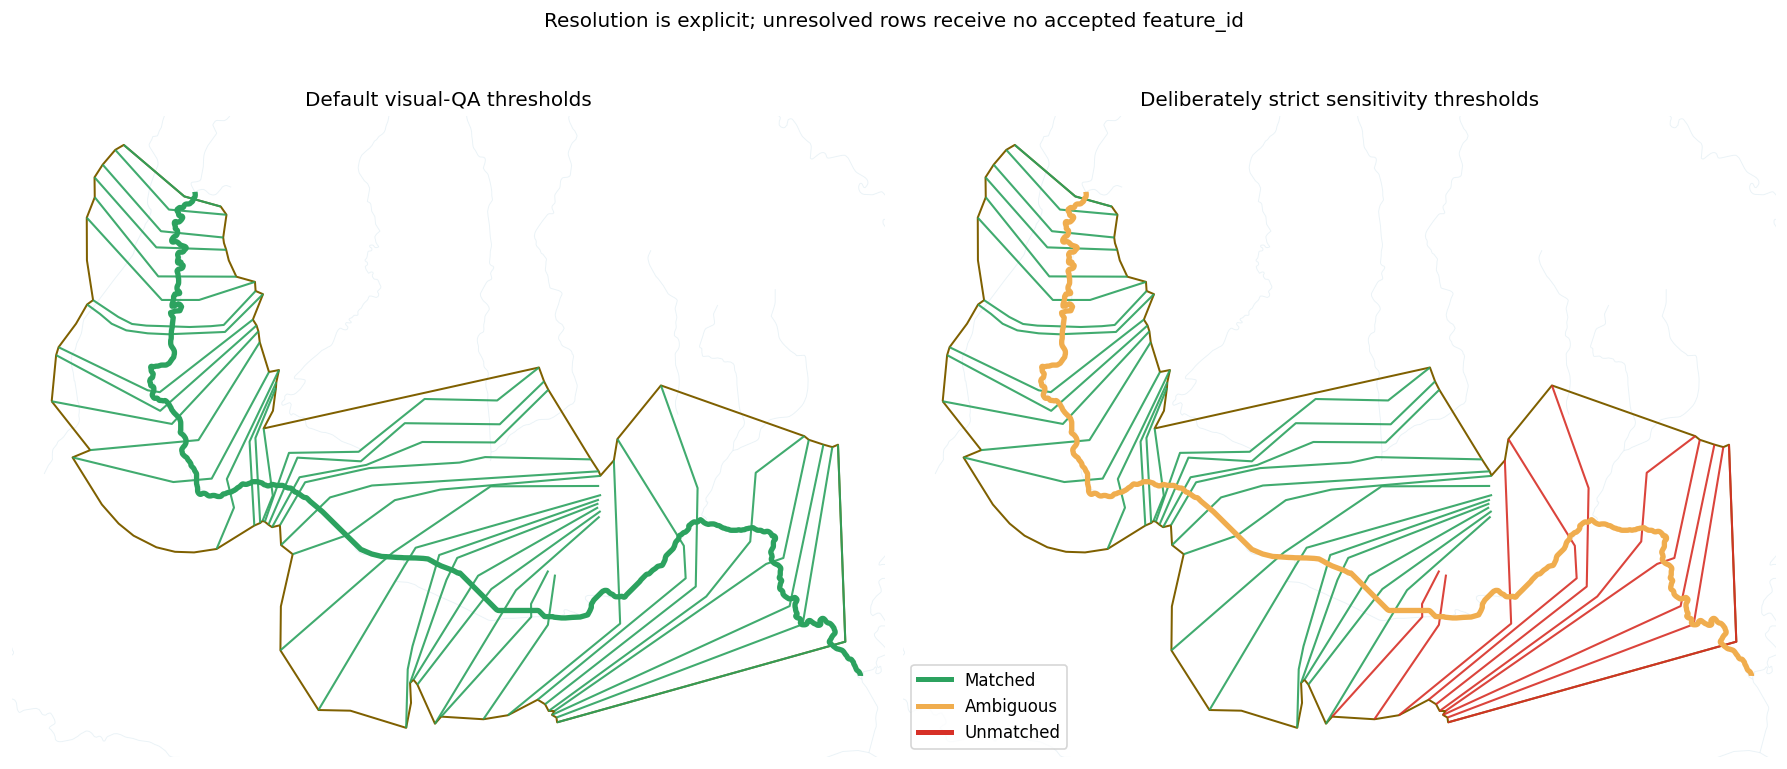

In [11]:
status_colors = {"matched": "#2ca25f", "ambiguous": "#f0ad4e", "unmatched": "#d73027"}


def plot_status(ax, conflation, title):
    flowpaths_model.plot(ax=ax, color="#d8e8f0", linewidth=0.55, alpha=0.55)
    model_footprints.boundary.plot(ax=ax, color="#7f6000", linewidth=1.2)
    elements = conflation.matches.to_crs(model_crs)
    for status in status_order:
        subset = elements.loc[
            (elements.element_type == "cross_section") & (elements.status == status)
        ]
        if not subset.empty:
            subset.plot(ax=ax, color=status_colors[status], linewidth=1.25, alpha=0.9)
    reach = elements.loc[elements.element_type == "reach"]
    reach.plot(ax=ax, color=[status_colors[s] for s in reach.status], linewidth=3.2)
    xmin, ymin, xmax, ymax = model_footprints.total_bounds
    xp, yp = (xmax - xmin) * 0.05, (ymax - ymin) * 0.05
    ax.set(xlim=(xmin - xp, xmax + xp), ylim=(ymin - yp, ymax + yp), aspect="equal")
    ax.set_axis_off()
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharex=True, sharey=True)
plot_status(axes[0], result, "Default visual-QA thresholds")
plot_status(axes[1], strict_result, "Deliberately strict sensitivity thresholds")
axes[1].legend(
    handles=[
        Line2D([0], [0], color=c, lw=3, label=s.title())
        for s, c in status_colors.items()
    ],
    loc="lower left",
)
fig.suptitle(
    "Resolution is explicit; unresolved rows receive no accepted feature_id", y=1.02
)
plt.tight_layout()
plt.show()

## 6. Verify along-flowpath measures and XS sequence

Accepted XS links receive measure, fraction, distance from end, method, and
offset. Measure points should progress monotonically with HEC-RAS river station.


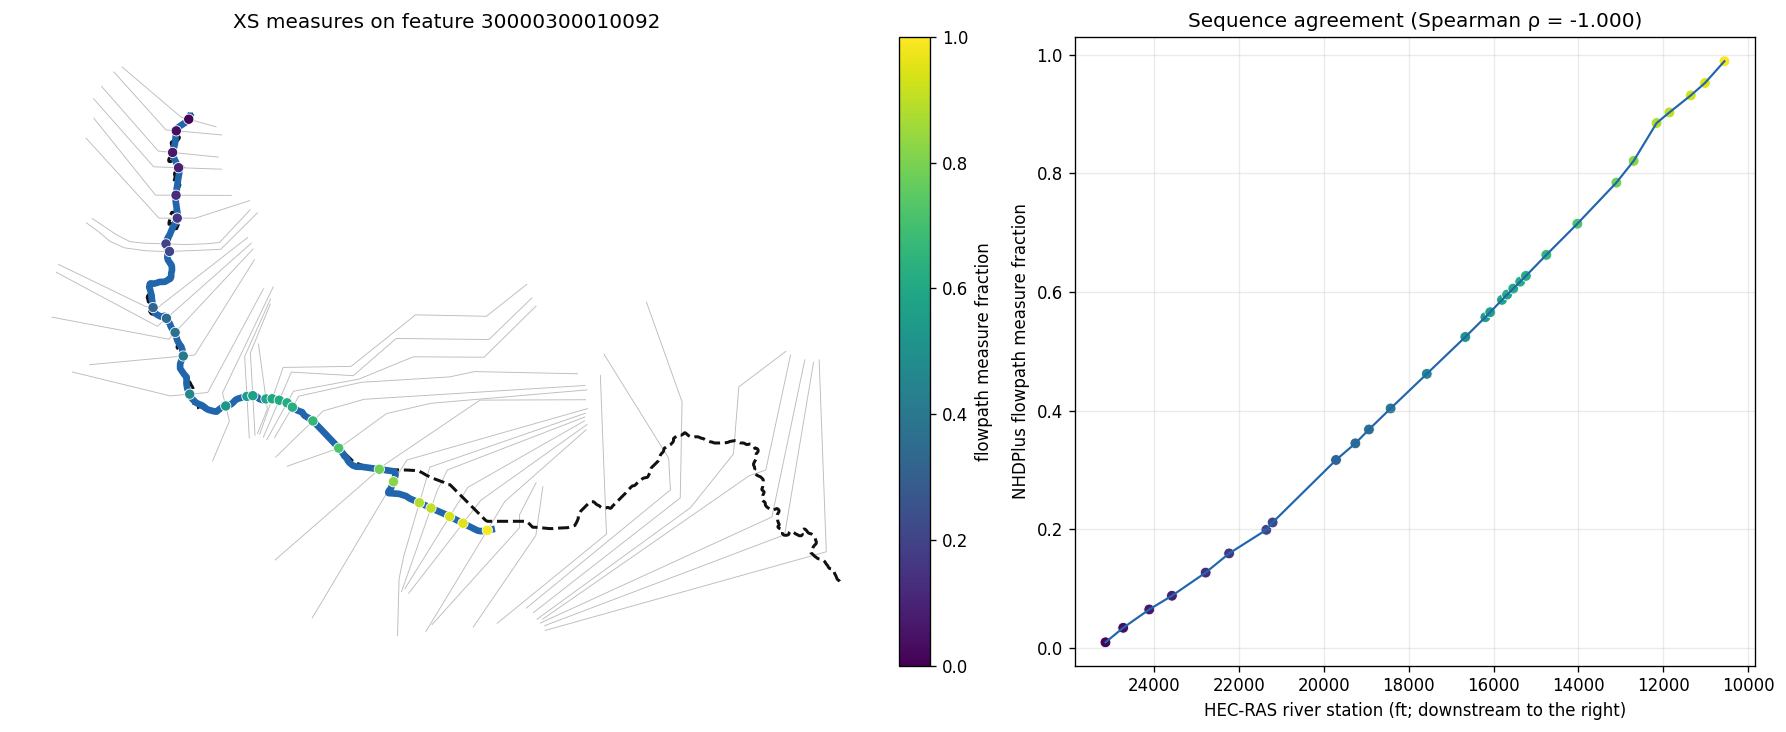

,xs_id,feature_id,flowpath_measure,flowpath_measure_fraction,flowpath_measure_from_end,measure_method,offset_distance
33,25147,30000300010092,129.679787,0.009361,13722.864394,intersection,0.0
32,24729,30000300010092,469.135611,0.033866,13383.408570,intersection,0.0
31,24115,30000300010092,897.240862,0.064771,12955.303319,intersection,0.0
30,23581,30000300010092,1217.566576,0.087895,12634.977604,intersection,0.0
29,22786,30000300010092,1758.187598,0.126922,12094.356582,intersection,0.0
28,22233,30000300010092,2206.237304,0.159266,11646.306876,intersection,0.0
27,21356,30000300010092,2757.519726,0.199062,11095.024455,intersection,0.0
26,21208,30000300010092,2929.335652,0.211466,10923.208529,intersection,0.0
24,19714,30000300010092,4388.926943,0.316832,9463.617238,intersection,0.0
23,19258,30000300010092,4777.153026,0.344857,9075.391154,intersection,0.0


In [12]:
dominant_id = str(reach_match.feature_id)
xs_matches = result.matches.loc[
    (result.matches.element_type == "cross_section")
    & (result.matches.feature_id.astype(str) == dominant_id)
].copy()
xs_matches["river_station"] = pd.to_numeric(xs_matches.xs_id, errors="coerce")
xs_matches = xs_matches.sort_values("river_station", ascending=False)
measure_points = gpd.GeoDataFrame(
    xs_matches.drop(columns="geometry"),
    geometry=[top_flowpath.interpolate(float(v)) for v in xs_matches.flowpath_measure],
    crs=result.analysis_crs,
)
rho = xs_matches.river_station.corr(
    xs_matches.flowpath_measure_fraction, method="spearman"
)
fig, (amap, aseq) = plt.subplots(
    1, 2, figsize=(15, 6.2), gridspec_kw={"width_ratios": [1.35, 1]}
)
cross_sections.plot(ax=amap, color="#bdbdbd", linewidth=0.55)
centerlines.plot(ax=amap, color="#111111", linewidth=1.8, linestyle="--")
gpd.GeoSeries([top_flowpath], crs=result.analysis_crs).plot(
    ax=amap, color="#2166ac", linewidth=4
)
scatter = amap.scatter(
    measure_points.geometry.x,
    measure_points.geometry.y,
    c=measure_points.flowpath_measure_fraction,
    cmap="viridis",
    vmin=0,
    vmax=1,
    s=38,
    edgecolor="white",
    linewidth=0.5,
    zorder=8,
)
amap.set_aspect("equal")
amap.set_axis_off()
amap.set_title(f"XS measures on feature {dominant_id}")
fig.colorbar(
    scatter, ax=amap, fraction=0.035, pad=0.02, label="flowpath measure fraction"
)
aseq.plot(
    xs_matches.river_station,
    xs_matches.flowpath_measure_fraction,
    color="#2166ac",
    lw=1.3,
)
aseq.scatter(
    xs_matches.river_station,
    xs_matches.flowpath_measure_fraction,
    c=xs_matches.flowpath_measure_fraction,
    cmap="viridis",
    vmin=0,
    vmax=1,
    s=42,
    edgecolor="white",
    linewidth=0.5,
)
aseq.invert_xaxis()
aseq.set_ylim(-0.03, 1.03)
aseq.grid(alpha=0.25)
aseq.set_xlabel("HEC-RAS river station (ft; downstream to the right)")
aseq.set_ylabel("NHDPlus flowpath measure fraction")
aseq.set_title(f"Sequence agreement (Spearman ρ = {rho:.3f})")
plt.tight_layout()
plt.show()
display(
    xs_matches[
        [
            "xs_id",
            "feature_id",
            "flowpath_measure",
            "flowpath_measure_fraction",
            "flowpath_measure_from_end",
            "measure_method",
            "offset_distance",
        ]
    ].head(10)
)

## 7. Review HUC intersections and output invariants

HUC intersections are separate from scoring. These checks verify the output
contract without asserting that an external feature must always win as USGS
data evolves.


In [13]:
huc_review = result.huc_intersections.drop(columns="geometry").copy()
huc_review["intersection_sq_miles"] = huc_review.intersection_area / (5280.0**2)
display(
    huc_review[
        [
            "geometry_id",
            "huc_id",
            "intersection_sq_miles",
            "geometry_area_fraction",
            "huc_area_fraction",
        ]
    ]
)
assert result.candidates.confidence_score.between(0, 1).all()
assert result.matches.loc[result.matches.status != "matched", "feature_id"].isna().all()
assert result.matches.flowpath_measure_fraction.dropna().between(0, 1).all()
assert result.huc_intersections.geometry_area_fraction.between(0, 1).all()
display(
    pd.Series(
        {
            "candidate scores bounded [0, 1]": True,
            "unresolved accepted feature_id values null": True,
            "measure fractions bounded [0, 1]": True,
            "HUC fractions bounded [0, 1]": True,
        },
        name="passed",
    ).to_frame()
)

,geometry_id,huc_id,intersection_sq_miles,geometry_area_fraction,huc_area_fraction
0,lower-colorado-cummins-shiloh-branch,120903010507,2.888101,1.0,0.053936


,passed
"candidate scores bounded [0, 1]",True
unresolved accepted feature_id values null,True
"measure fractions bounded [0, 1]",True
"HUC fractions bounded [0, 1]",True


## Reviewer checklist and next steps

1. Confirm model and flowpaths overlap on the alignment map.
2. Compare rank 1 with alternatives and inspect direct XS intersections.
3. Confirm the winning score uses several independent evidence types.
4. Confirm unresolved rows have null accepted IDs but retain candidate evidence.
5. Confirm accepted XS measures progress monotonically along the flowpath.

The same call accepts `adapter="nwm"` or `adapter="nextgen"`. Production
thresholds and weights belong to the consuming workflow and are intentionally
not encoded here.
